In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)


def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "255-AI" / "pyproject.toml").is_file():
        return (cwd / "255-AI").resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "pyproject.toml").is_file():
            return base
    return cwd


PROJECT_ROOT = _find_project_root()
ONET_RAW = PROJECT_ROOT / "data" / "raw" / "onet"
PATH_ABILITIES = ONET_RAW / "Abilities.xlsx"
PATH_WORKACTS = ONET_RAW / "Work Activities.xlsx"
PATH_OCC = ONET_RAW / "Occupation Data.xlsx"

In [8]:
## Section 1 — Load Data

In [9]:
# Load all three files
_onet_inputs = [PATH_ABILITIES, PATH_WORKACTS, PATH_OCC]
_missing = [p for p in _onet_inputs if not p.is_file()]
if _missing:
    raise FileNotFoundError(
        "O*NET Excel files not found.\n"
        f"  Put them in: {ONET_RAW}\n"
        "  Download the O*NET Database (Excel) from https://www.onetcenter.org/database.html\n"
        "  and copy at least: Abilities.xlsx, Work Activities.xlsx, Occupation Data.xlsx\n"
        f"  Missing: {[p.name for p in _missing]}"
    )

abilities  = pd.read_excel(PATH_ABILITIES, dtype={'O*NET-SOC Code': str})
work_acts  = pd.read_excel(PATH_WORKACTS,  dtype={'O*NET-SOC Code': str})
occ_data   = pd.read_excel(PATH_OCC,       dtype={'O*NET-SOC Code': str})

print(f"Abilities rows:     {len(abilities):,}")
print(f"Work Activities rows: {len(work_acts):,}")
print(f"Occupation Data rows: {len(occ_data):,}")

Abilities rows:     92,976
Work Activities rows: 73,308
Occupation Data rows: 1,016


In [10]:
# Normalize SOC codes: O*NET uses 11-1011.00, we need 11-1011
for df in [abilities, work_acts, occ_data]:
    df['OCC_CODE'] = df['O*NET-SOC Code'].str[:7]

# Filter to Importance scale (IM) only — drop Level (LV) rows
abilities_im = abilities[abilities['Scale ID'] == 'IM'].copy()
work_acts_im = work_acts[work_acts['Scale ID'] == 'IM'].copy()

print(f"Abilities (IM only): {len(abilities_im):,} rows")
print(f"Work Activities (IM only): {len(work_acts_im):,} rows")

Abilities (IM only): 46,488 rows
Work Activities (IM only): 36,654 rows


## Section 2 — See the Data

In [11]:
# 2.1 Abilities (IM scale)
print("=" * 60)
print("ABILITIES — first 5 rows (Importance scale only)")
print("=" * 60)
display(abilities_im[['OCC_CODE', 'Title', 'Element Name', 
                        'Scale ID', 'Data Value']].head())

ABILITIES — first 5 rows (Importance scale only)


,OCC_CODE,Title,Element Name,Scale ID,Data Value
0,11-1011,Chief Executives,Oral Comprehension,IM,4.62
2,11-1011,Chief Executives,Written Comprehension,IM,4.25
4,11-1011,Chief Executives,Oral Expression,IM,4.50
6,11-1011,Chief Executives,Written Expression,IM,4.12
8,11-1011,Chief Executives,Fluency of Ideas,IM,3.88


In [12]:
# 2.2 Work Activities (IM scale) 
print("=" * 60)
print("WORK ACTIVITIES — first 5 rows (Importance scale only)")
print("=" * 60)
display(work_acts_im[['OCC_CODE', 'Title', 'Element Name',
                       'Scale ID', 'Data Value']].head())

WORK ACTIVITIES — first 5 rows (Importance scale only)


,OCC_CODE,Title,Element Name,Scale ID,Data Value
0,11-1011,Chief Executives,Getting Information,IM,4.56
2,11-1011,Chief Executives,"Monitoring Processes, Materials, or Surroundings",IM,4.25
4,11-1011,Chief Executives,"Identifying Objects, Actions, and Events",IM,4.23
6,11-1011,Chief Executives,"Inspecting Equipment, Structures, or Materials",IM,2.51
8,11-1011,Chief Executives,Estimating the Quantifiable Characteristics of...,IM,3.26


In [13]:
# 2.3 Occupation master list 
print("=" * 60)
print("OCCUPATION DATA — first 5 rows")
print("=" * 60)
display(occ_data.head())

OCCUPATION DATA — first 5 rows


,O*NET-SOC Code,Title,Description,OCC_CODE
0,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,11-1011
1,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh...",11-1011
2,11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ...",11-1021
3,11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes...",11-1031
4,11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici...",11-2011


In [14]:
# 2.4 Basic counts 
n_occ_ab = abilities_im['OCC_CODE'].nunique()
n_occ_wa = work_acts_im['OCC_CODE'].nunique()
n_abilities = abilities_im['Element Name'].nunique()
n_workacts  = work_acts_im['Element Name'].nunique()

print(f"Unique occupations in Abilities:      {n_occ_ab}")
print(f"Unique occupations in Work Activities: {n_occ_wa}")
print(f"Unique ability elements:               {n_abilities}")
print(f"Unique work activity elements:         {n_workacts}")
print(f"Total features (93 expected):          {n_abilities + n_workacts}")

Unique occupations in Abilities:      774
Unique occupations in Work Activities: 774
Unique ability elements:               52
Unique work activity elements:         41
Total features (93 expected):          93


## Section 3 — Data Quality Assessment

In [15]:
# 3.1 Missing Values
def missing_report(df, name):
    total = len(df)
    missing = df.isnull().sum()
    missing_pct = (missing / total * 100).round(2)
    report = pd.DataFrame({'missing_count': missing,
                           'missing_pct': missing_pct})
    report = report[report['missing_count'] > 0].sort_values(
        'missing_pct', ascending=False)
    print(f"\n── {name} — Missing Values ─────────────────")
    if report.empty:
        print("  No missing values found.")
    else:
        print(report.to_string())

missing_report(abilities_im,  'Abilities (IM)')
missing_report(work_acts_im,  'Work Activities (IM)')
missing_report(occ_data,      'Occupation Data')

# Check specifically for missing Data Values
ab_missing_vals  = abilities_im['Data Value'].isnull().sum()
wa_missing_vals  = work_acts_im['Data Value'].isnull().sum()

print(f"Missing Data Values in Abilities:      {ab_missing_vals}")
print(f"Missing Data Values in Work Activities: {wa_missing_vals}")


── Abilities (IM) — Missing Values ─────────────────
              missing_count  missing_pct
Not Relevant          46488        100.0

── Work Activities (IM) — Missing Values ─────────────────
                    missing_count  missing_pct
Not Relevant                36654       100.00
Lower CI Bound               9274        25.30
Upper CI Bound               9274        25.30
Standard Error               9266        25.28
Recommend Suppress           8651        23.60
N                             656         1.79

── Occupation Data — Missing Values ─────────────────
  No missing values found.
Missing Data Values in Abilities:      0
Missing Data Values in Work Activities: 0


In [16]:
# 3.2 Duplicates

# Each occupation-element pair should appear exactly once per Scale ID
ab_dups = abilities_im.duplicated(
    subset=['OCC_CODE', 'Element Name', 'Scale ID']).sum()
wa_dups = work_acts_im.duplicated(
    subset=['OCC_CODE', 'Element Name', 'Scale ID']).sum()

print(f"Duplicate occupation-element pairs in Abilities:      {ab_dups}")
print(f"Duplicate occupation-element pairs in Work Activities: {wa_dups}")

if ab_dups > 0:
    print("\nAbilities duplicate rows:")
    display(abilities_im[abilities_im.duplicated(
        subset=['OCC_CODE', 'Element Name', 'Scale ID'], keep=False)])

if wa_dups > 0:
    print("\nWork Activities duplicate rows:")
    display(work_acts_im[work_acts_im.duplicated(
        subset=['OCC_CODE', 'Element Name', 'Scale ID'], keep=False)])

Duplicate occupation-element pairs in Abilities:      6240
Duplicate occupation-element pairs in Work Activities: 4920

Abilities duplicate rows:


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source,OCC_CODE
0,11-1011.00,Chief Executives,1.A.1.a.1,Oral Comprehension,IM,Importance,4.62,8,0.1830,4.2664,4.9836,N,NaN,08/2023,Analyst,11-1011
2,11-1011.00,Chief Executives,1.A.1.a.2,Written Comprehension,IM,Importance,4.25,8,0.1637,3.9292,4.5708,N,NaN,08/2023,Analyst,11-1011
4,11-1011.00,Chief Executives,1.A.1.a.3,Oral Expression,IM,Importance,4.50,8,0.1890,4.1296,4.8704,N,NaN,08/2023,Analyst,11-1011
6,11-1011.00,Chief Executives,1.A.1.a.4,Written Expression,IM,Importance,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst,11-1011
8,11-1011.00,Chief Executives,1.A.1.b.1,Fluency of Ideas,IM,Importance,3.88,8,0.1250,3.6300,4.1200,N,NaN,08/2023,Analyst,11-1011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92134,53-7062.04,Recycling and Reclamation Workers,1.A.4.b.1,Hearing Sensitivity,IM,Importance,2.38,8,0.2631,1.8594,2.8906,N,NaN,07/2012,Analyst,53-7062
92136,53-7062.04,Recycling and Reclamation Workers,1.A.4.b.2,Auditory Attention,IM,Importance,2.38,8,0.2631,1.8594,2.8906,N,NaN,07/2012,Analyst,53-7062
92138,53-7062.04,Recycling and Reclamation Workers,1.A.4.b.3,Sound Localization,IM,Importance,1.75,8,0.1637,1.4292,2.0708,N,NaN,07/2012,Analyst,53-7062
92140,53-7062.04,Recycling and Reclamation Workers,1.A.4.b.4,Speech Recognition,IM,Importance,2.88,8,0.1250,2.6300,3.1200,N,NaN,07/2012,Analyst,53-7062



Work Activities duplicate rows:


,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source,OCC_CODE
0,11-1011.00,Chief Executives,4.A.1.a.1,Getting Information,IM,Importance,4.56,29.0,0.1559,4.2369,4.8756,N,NaN,08/2023,Incumbent,11-1011
2,11-1011.00,Chief Executives,4.A.1.a.2,"Monitoring Processes, Materials, or Surroundings",IM,Importance,4.25,30.0,0.2125,3.8130,4.6823,N,NaN,08/2023,Incumbent,11-1011
4,11-1011.00,Chief Executives,4.A.1.b.1,"Identifying Objects, Actions, and Events",IM,Importance,4.23,29.0,0.1544,3.9180,4.5507,N,NaN,08/2023,Incumbent,11-1011
6,11-1011.00,Chief Executives,4.A.1.b.2,"Inspecting Equipment, Structures, or Materials",IM,Importance,2.51,29.0,0.2813,1.9346,3.0871,N,NaN,08/2023,Incumbent,11-1011
8,11-1011.00,Chief Executives,4.A.1.b.3,Estimating the Quantifiable Characteristics of...,IM,Importance,3.26,30.0,0.2750,2.6958,3.8208,N,NaN,08/2023,Incumbent,11-1011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72642,53-7062.04,Recycling and Reclamation Workers,4.A.4.b.5,Coaching and Developing Others,IM,Importance,3.17,18.0,0.4889,2.1410,4.2040,N,NaN,07/2012,Incumbent,53-7062
72644,53-7062.04,Recycling and Reclamation Workers,4.A.4.b.6,Providing Consultation and Advice to Others,IM,Importance,2.01,18.0,0.4055,1.1567,2.8677,N,NaN,07/2012,Incumbent,53-7062
72646,53-7062.04,Recycling and Reclamation Workers,4.A.4.c.1,Performing Administrative Activities,IM,Importance,2.64,18.0,0.4691,1.6474,3.6269,N,NaN,07/2012,Incumbent,53-7062
72648,53-7062.04,Recycling and Reclamation Workers,4.A.4.c.2,Staffing Organizational Units,IM,Importance,2.07,18.0,0.5173,1.0000,3.1602,N,NaN,07/2012,Incumbent,53-7062


In [17]:
# 3.3 Outliers and Anomalies

# Data Value range — IM scale should be 1.0 to 5.0
print("Abilities Data Value range (IM scale, expected 1–5):")
print(abilities_im['Data Value'].describe().round(3))

print("\nWork Activities Data Value range (IM scale, expected 1–5):")
print(work_acts_im['Data Value'].describe().round(3))

# Flag any values outside expected 1–5 range
ab_out_of_range = abilities_im[
    (abilities_im['Data Value'] < 1) | (abilities_im['Data Value'] > 5)]
wa_out_of_range = work_acts_im[
    (work_acts_im['Data Value'] < 1) | (work_acts_im['Data Value'] > 5)]

print(f"Abilities values outside 1–5:      {len(ab_out_of_range)}")
print(f"Work Activities values outside 1–5: {len(wa_out_of_range)}")

if len(ab_out_of_range) > 0:
    display(ab_out_of_range[['OCC_CODE', 'Title', 'Element Name', 'Data Value']])
if len(wa_out_of_range) > 0:
    display(wa_out_of_range[['OCC_CODE', 'Title', 'Element Name', 'Data Value']])

    # Check Recommend Suppress flag — these are rows O*NET flags as unreliable
ab_suppress = abilities_im[abilities_im['Recommend Suppress'] == 'Y']
wa_suppress = work_acts_im[work_acts_im['Recommend Suppress'] == 'Y']

print(f"Abilities rows flagged Recommend Suppress=Y: {len(ab_suppress)}")
print(f"Work Activities rows flagged Recommend Suppress=Y: {len(wa_suppress)}")

# Show which occupations are affected
if len(ab_suppress) > 0:
    print("\nAffected occupations (Abilities):")
    print(ab_suppress[['OCC_CODE', 'Title', 'Element Name',
                        'Data Value']].to_string(index=False))

Abilities Data Value range (IM scale, expected 1–5):
count    46488.000
mean         2.477
std          0.914
min          1.000
25%          1.880
50%          2.620
75%          3.120
max          5.000
Name: Data Value, dtype: float64

Work Activities Data Value range (IM scale, expected 1–5):
count    36654.000
mean         3.152
std          0.860
min          1.000
25%          2.550
50%          3.230
75%          3.820
max          4.990
Name: Data Value, dtype: float64
Abilities values outside 1–5:      0
Work Activities values outside 1–5: 0
Abilities rows flagged Recommend Suppress=Y: 0
Work Activities rows flagged Recommend Suppress=Y: 1


In [18]:
# 3.4 Data Completeness and Consistency

# How many occupations have ALL ability elements rated?
# Expected: n_abilities scores per occupation
ab_counts = (abilities_im.groupby('OCC_CODE')['Element Name']
                          .nunique()
                          .reset_index()
                          .rename(columns={'Element Name': 'n_abilities_rated'}))

print(f"Expected abilities per occupation: {n_abilities}")
print(f"\nAbility count distribution:")
print(ab_counts['n_abilities_rated'].value_counts().sort_index())

incomplete_ab = ab_counts[ab_counts['n_abilities_rated'] < n_abilities]
print(f"\nOccupations with incomplete ability ratings: {len(incomplete_ab)}")
if len(incomplete_ab) > 0:
    display(incomplete_ab.head(10))

# Same check for work activities
wa_counts = (work_acts_im.groupby('OCC_CODE')['Element Name']
                          .nunique()
                          .reset_index()
                          .rename(columns={'Element Name': 'n_workacts_rated'}))

print(f"Expected work activities per occupation: {n_workacts}")
print(f"\nWork activity count distribution:")
print(wa_counts['n_workacts_rated'].value_counts().sort_index())

incomplete_wa = wa_counts[wa_counts['n_workacts_rated'] < n_workacts]
print(f"\nOccupations with incomplete work activity ratings: {len(incomplete_wa)}")

Expected abilities per occupation: 52

Ability count distribution:
n_abilities_rated
52    774
Name: count, dtype: int64

Occupations with incomplete ability ratings: 0
Expected work activities per occupation: 41

Work activity count distribution:
n_workacts_rated
41    774
Name: count, dtype: int64

Occupations with incomplete work activity ratings: 0


In [19]:
# SOC code format consistency check — all should be XX-XXXX
ab_format_ok = abilities_im['OCC_CODE'].str.match(r'^\d{2}-\d{4}$').all()
wa_format_ok = work_acts_im['OCC_CODE'].str.match(r'^\d{2}-\d{4}$').all()

print(f"Abilities SOC codes all XX-XXXX format:      {ab_format_ok}")
print(f"Work Activities SOC codes all XX-XXXX format: {wa_format_ok}")

# Check occupations in Abilities vs Work Activities
ab_occs = set(abilities_im['OCC_CODE'].unique())
wa_occs = set(work_acts_im['OCC_CODE'].unique())

in_ab_not_wa = ab_occs - wa_occs
in_wa_not_ab = wa_occs - ab_occs

print(f"\nOccupations in Abilities but not Work Activities: {len(in_ab_not_wa)}")
print(f"Occupations in Work Activities but not Abilities: {len(in_wa_not_ab)}")

if in_ab_not_wa:
    print("\nIn Abilities only:", list(in_ab_not_wa)[:10])
if in_wa_not_ab:
    print("In Work Activities only:", list(in_wa_not_ab)[:10])

Abilities SOC codes all XX-XXXX format:      True
Work Activities SOC codes all XX-XXXX format: True

Occupations in Abilities but not Work Activities: 0
Occupations in Work Activities but not Abilities: 0


## Section 4 — Pattern Discovery

In [20]:
# 4.1 Pivot to Wide Format

# Pivot abilities to wide: one row per occupation, one col per ability
ab_wide = (abilities_im
           .pivot_table(index='OCC_CODE',
                        columns='Element Name',
                        values='Data Value',
                        aggfunc='mean')  # aggfunc=mean handles any rare duplicates
           .reset_index())

# Pivot work activities to wide
wa_wide = (work_acts_im
           .pivot_table(index='OCC_CODE',
                        columns='Element Name',
                        values='Data Value',
                        aggfunc='mean')
           .reset_index())

print(f"Abilities wide:      {ab_wide.shape}  (occupations × abilities)")
print(f"Work Activities wide: {wa_wide.shape}  (occupations × work activities)")

Abilities wide:      (774, 53)  (occupations × abilities)
Work Activities wide: (774, 42)  (occupations × work activities)


In [21]:
# Merge abilities + work activities into one wide feature table
onet = ab_wide.merge(wa_wide, on='OCC_CODE', suffixes=('_ab', '_wa'))

# Clean column names
onet.columns = [
    col.strip().lower()
       .replace(' ', '_')
       .replace('/', '_')
       .replace('-', '_')
       .replace('(', '')
       .replace(')', '')
    for col in onet.columns
]

# Add occupation title
title_map = (abilities_im[['OCC_CODE', 'Title']]
             .drop_duplicates(subset='OCC_CODE')
             .rename(columns={'Title': 'OCC_TITLE'}))
onet = onet.merge(title_map, left_on='occ_code',
                  right_on='OCC_CODE', how='left').drop(columns='OCC_CODE')

# Add major occupation group label
onet['occ_major_group'] = onet['occ_code'].str[:2].map({
    '11': 'Management',
    '13': 'Business & Financial',
    '15': 'Computer & Math',
    '17': 'Architecture & Engineering',
    '19': 'Life, Physical & Social Science',
    '21': 'Community & Social Service',
    '23': 'Legal',
    '25': 'Education',
    '27': 'Arts & Entertainment',
    '29': 'Healthcare Practitioners',
    '31': 'Healthcare Support',
    '33': 'Protective Service',
    '35': 'Food Preparation',
    '37': 'Building & Grounds',
    '39': 'Personal Care',
    '41': 'Sales',
    '43': 'Office & Admin Support',
    '45': 'Farming & Fishing',
    '47': 'Construction',
    '49': 'Installation & Repair',
    '51': 'Production',
    '53': 'Transportation',
})

print(f"Final O*NET wide table: {onet.shape}")
display(onet[['occ_code', 'OCC_TITLE', 'occ_major_group']].head())

Final O*NET wide table: (774, 96)


,occ_code,OCC_TITLE,occ_major_group
0,11-1011,Chief Executives,Management
1,11-1021,General and Operations Managers,Management
2,11-2011,Advertising and Promotions Managers,Management
3,11-2021,Marketing Managers,Management
4,11-2022,Sales Managers,Management


In [22]:
# 4.2 Distribution of Scores Across All Features

feature_cols = [c for c in onet.columns 
                if c not in ['occ_code', 'OCC_TITLE', 'occ_major_group']]

# Overall distribution of all importance scores
all_vals = onet[feature_cols].values.flatten()
all_vals = all_vals[~np.isnan(all_vals)]

print(f"Total feature values: {len(all_vals):,}")
print(f"Mean:   {all_vals.mean():.3f}")
print(f"Median: {np.median(all_vals):.3f}")
print(f"Std:    {all_vals.std():.3f}")
print(f"Min:    {all_vals.min():.3f}")
print(f"Max:    {all_vals.max():.3f}")

Total feature values: 71,982
Mean:   2.767
Median: 2.880
Std:    0.935
Min:    1.000
Max:    5.000


In [23]:
# 4.3 Mean Importance Score Per Feature
# Which abilities and work activities are most important on average?

# Build name sets from raw files to correctly identify columns
ability_names = set(
    abilities_im['Element Name']
    .str.strip().str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .unique()
)

workact_names = set(
    work_acts_im['Element Name']
    .str.strip().str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .unique()
)

feature_cols = [c for c in onet.columns
                if c not in ['occ_code', 'OCC_TITLE', 'occ_major_group']]
ab_cols = [c for c in feature_cols if c in ability_names]
wa_cols = [c for c in feature_cols if c in workact_names]

ab_means = onet[ab_cols].mean().sort_values(ascending=False)
wa_means = onet[wa_cols].mean().sort_values(ascending=False)

print("Top 10 Abilities by mean importance:")
print(ab_means.head(10).round(3).to_string())
print("\nTop 10 Work Activities by mean importance:")
print(wa_means.head(10).round(3).to_string())

Top 10 Abilities by mean importance:
oral_comprehension       3.697
oral_expression          3.673
near_vision              3.594
problem_sensitivity      3.568
written_comprehension    3.478
deductive_reasoning      3.454
speech_clarity           3.411
inductive_reasoning      3.369
speech_recognition       3.365
information_ordering     3.343

Top 10 Work Activities by mean importance:
getting_information                                         4.198
communicating_with_supervisors,_peers,_or_subordinates      3.976
making_decisions_and_solving_problems                       3.950
identifying_objects,_actions,_and_events                    3.828
updating_and_using_relevant_knowledge                       3.744
organizing,_planning,_and_prioritizing_work                 3.670
establishing_and_maintaining_interpersonal_relationships    3.663
documenting_recording_information                           3.597
processing_information                                      3.581
monitoring_proc

## Section 5 — Visualizations and Summaries

ab_vals shape: (40248,), sample: [1.19  2.06  3.31  1.625 4.   ]
wa_vals shape: (31734,), sample: [4.3   3.025 4.32  4.515 4.78 ]


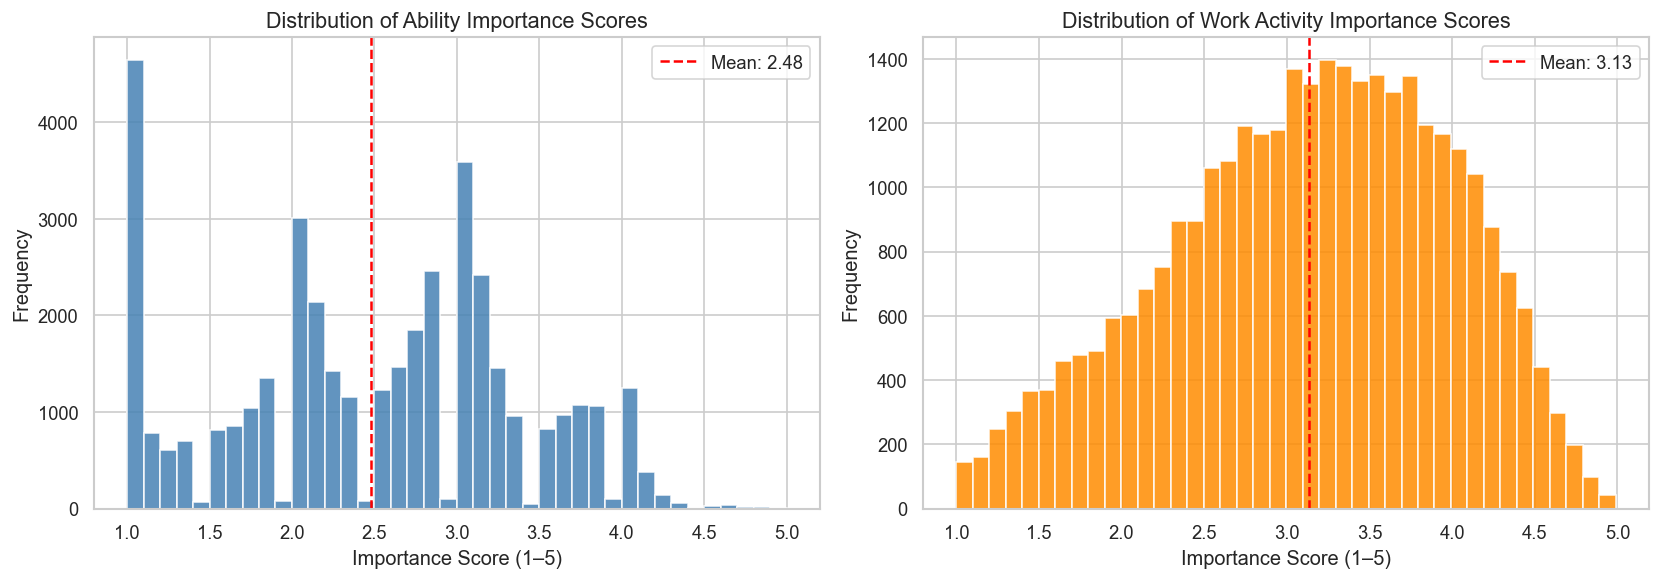

In [24]:
# 5.1 Distribution of All Importance Scores

ab_vals = onet[ab_cols].values.flatten().astype(float)
wa_vals = onet[wa_cols].values.flatten().astype(float)

print(f"ab_vals shape: {ab_vals.shape}, sample: {ab_vals[:5]}")
print(f"wa_vals shape: {wa_vals.shape}, sample: {wa_vals[:5]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Abilities
axes[0].hist(ab_vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Ability Importance Scores', fontsize=13)
axes[0].set_xlabel('Importance Score (1–5)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(ab_vals.mean(), color='red', linestyle='--',
                label=f'Mean: {ab_vals.mean():.2f}')
axes[0].legend()

# Work Activities
axes[1].hist(wa_vals, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Work Activity Importance Scores', fontsize=13)
axes[1].set_xlabel('Importance Score (1–5)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(wa_vals.mean(), color='red', linestyle='--',
                label=f'Mean: {wa_vals.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

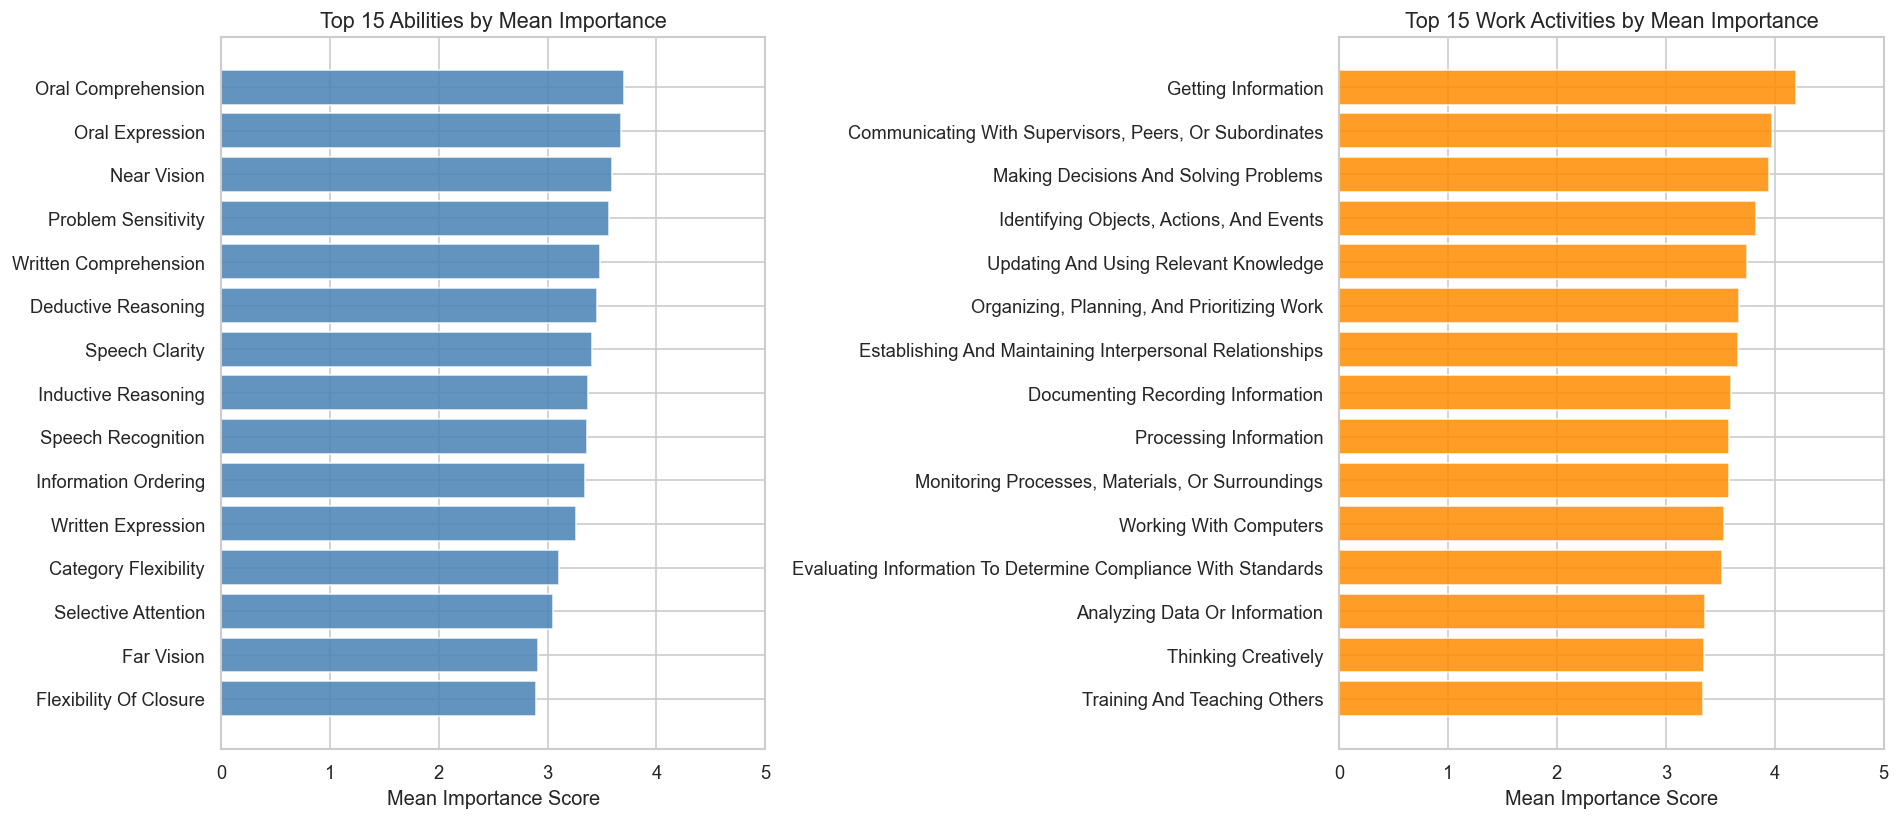

In [25]:
# 5.2 Top and Bottom Abilities by Mean Importance

def clean_label(col):
    return col.replace('_', ' ').title()

top15_ab = ab_means.head(15)
top15_wa = wa_means.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh([clean_label(c) for c in top15_ab.index[::-1]],
             top15_ab.values[::-1].astype(float),
             color='steelblue', alpha=0.85)
axes[0].set_title('Top 15 Abilities by Mean Importance', fontsize=13)
axes[0].set_xlabel('Mean Importance Score')
axes[0].set_xlim(0, 5)

axes[1].barh([clean_label(c) for c in top15_wa.index[::-1]],
             top15_wa.values[::-1].astype(float),
             color='darkorange', alpha=0.85)
axes[1].set_title('Top 15 Work Activities by Mean Importance', fontsize=13)
axes[1].set_xlabel('Mean Importance Score')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

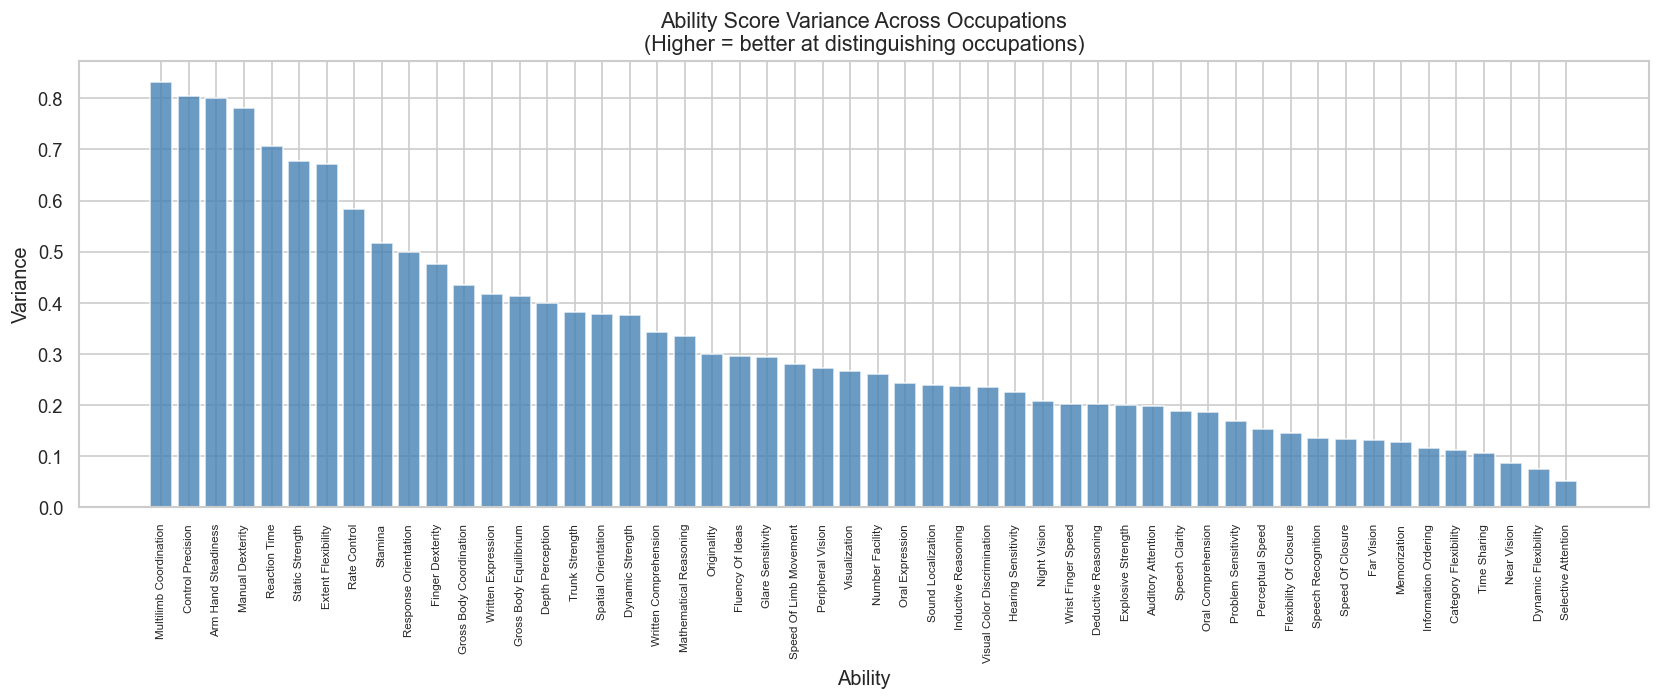

Top 10 highest variance abilities (best PCA candidates):
multilimb_coordination    0.8320
control_precision         0.8052
arm_hand_steadiness       0.8014
manual_dexterity          0.7810
reaction_time             0.7068
static_strength           0.6769
extent_flexibility        0.6711
rate_control              0.5843
stamina                   0.5175
response_orientation      0.5000

Bottom 10 lowest variance abilities (least discriminating):
speech_recognition      0.1363
speed_of_closure        0.1339
far_vision              0.1320
memorization            0.1284
information_ordering    0.1158
category_flexibility    0.1126
time_sharing            0.1070
near_vision             0.0874
dynamic_flexibility     0.0752
selective_attention     0.0521


In [26]:
# 5.3 Ability Score Variance

ab_var = onet[ab_cols].var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([clean_label(c) for c in ab_var.index],
       ab_var.values.astype(float),
       color='steelblue', alpha=0.8)
ax.set_title('Ability Score Variance Across Occupations\n'
             '(Higher = better at distinguishing occupations)', fontsize=13)
ax.set_ylabel('Variance')
ax.set_xlabel('Ability')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print("Top 10 highest variance abilities (best PCA candidates):")
print(ab_var.head(10).round(4).to_string())
print("\nBottom 10 lowest variance abilities (least discriminating):")
print(ab_var.tail(10).round(4).to_string())

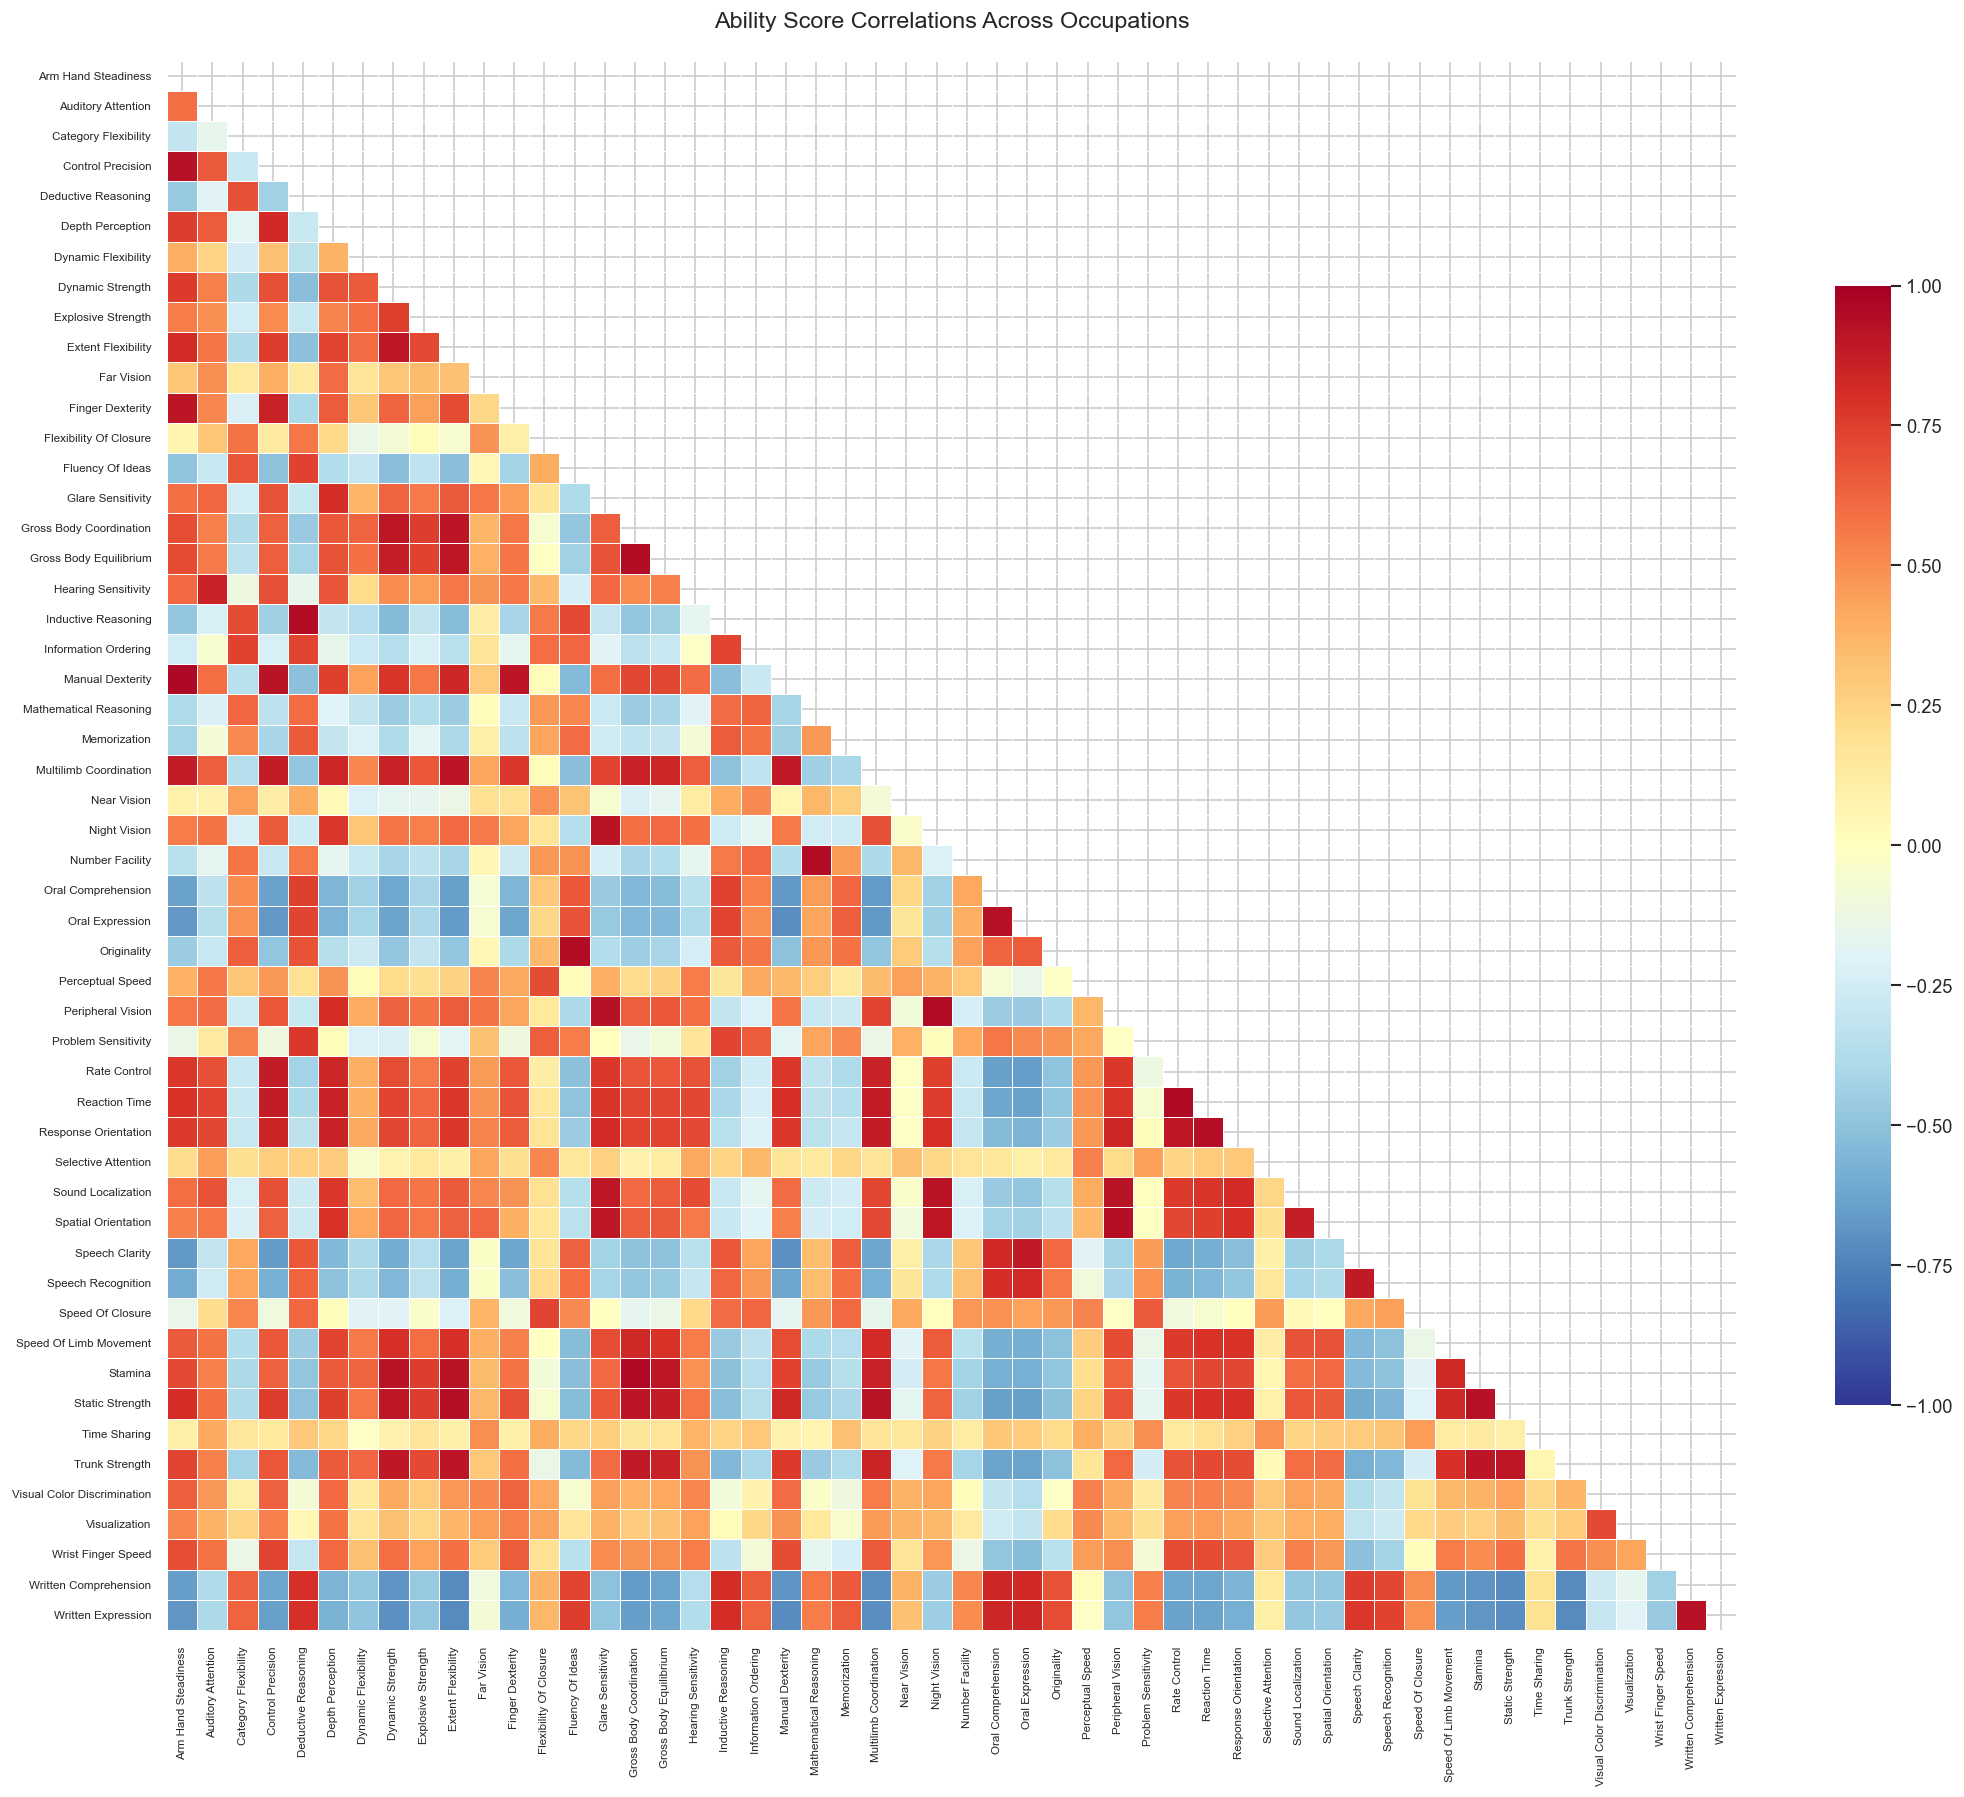

In [27]:
# 5.4 Correlation Heatmap — Abilities

ab_corr = onet[ab_cols].astype(float).corr()
ab_corr.index   = [clean_label(c) for c in ab_corr.index]
ab_corr.columns = [clean_label(c) for c in ab_corr.columns]

mask = np.triu(np.ones_like(ab_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(ab_corr, mask=mask, cmap='RdYlBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            annot=False, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Ability Score Correlations Across Occupations',
             fontsize=14, pad=20)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

### Summary Statistics

In [28]:
# Summary stats for all feature columns
summary = onet[feature_cols].describe().T
summary = summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary = summary.round(3)
summary.index = [clean_label(c) for c in summary.index]

print("Feature summary statistics (first 20 features):")
display(summary.head(20))

Feature summary statistics (first 20 features):


,count,mean,std,min,25%,50%,75%,max
Arm Hand Steadiness,774.0,2.609,0.895,1.00,2.00,2.88,3.250,4.25
Auditory Attention,774.0,2.403,0.445,1.38,2.00,2.25,2.750,4.00
Category Flexibility,774.0,3.109,0.336,2.00,3.00,3.12,3.250,4.00
Control Precision,774.0,2.450,0.897,1.00,1.75,2.50,3.120,4.62
Deductive Reasoning,774.0,3.454,0.449,2.00,3.12,3.38,3.880,4.62
Depth Perception,774.0,2.162,0.632,1.00,1.75,2.12,2.620,4.12
Dynamic Flexibility,774.0,1.152,0.274,1.00,1.00,1.00,1.250,3.62
Dynamic Strength,774.0,1.878,0.612,1.00,1.38,2.00,2.250,4.25
Explosive Strength,774.0,1.471,0.447,1.00,1.00,1.38,1.750,3.62
Extent Flexibility,774.0,2.069,0.819,1.00,1.19,2.12,2.750,4.50


In [29]:
out_dir = PROJECT_ROOT / "data" / "processed" / "onet"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'onet_cleaned.csv'
onet.to_csv(out_path, index=False)
print(f'Wrote {out_path.resolve()}  shape={onet.shape}')

Wrote /Users/av/Desktop/255/255-AI/data/processed/onet/onet_cleaned.csv  shape=(774, 96)
